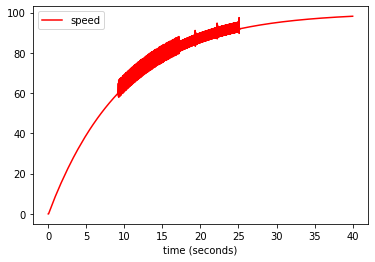

In [1]:
#
# to be tested with godot/ball
#

import arslabrobotics as ar

dp = ar.data.DataPlotter()
dp.set_x("time (seconds)")
dp.add_y("speed", "speed")

dds = ar.dds.DDS()
dds.start()

dds.subscribe(['speed'])
f = 500.0
dds.publish('force', f, ar.dds.DDS_TYPE_FLOAT)

data_file = open("ball_data.txt", "w")

t = ar.utils.Time()

t.start()
while t.get() < 40:
    
    v = dds.wait('speed')
    delta_t = t.elapsed()
    
    dp.append_x(t.get())
    dp.append_y("speed", v)
    
    data_file.write(f"{f} {v}\n")

dp.plot()
dds.publish('force', 0.0, ar.dds.DDS_TYPE_FLOAT)
data_file.close()
